# hBN Orthogonal NNSK-SCC smoke test

This notebook checks the orthogonal SCC path for an `NNSK(overlap=False)` checkpoint. The model supplies an orthogonal Hamiltonian, while SCC physical parameters such as Hubbard U, occupation, mass, and cutoff radii are read from the hBN DFTB SK files.

Expected behavior:

- `SKSCC` auto-detects `overlap=False` from the model.
- Mulliken charge uses the orthogonal limit `S = I`.
- SCC Hamiltonian correction is diagonal-only.
- No `AtomicDataDict.OVERLAP_KEY` is required or produced.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from ase.io import read

from dptb.data import AtomicDataDict
from dptb.nn.build import build_model
from dptb.nn.dftb.dftb_scc import SKSCC
from dptb.nn.dftb.sk_param import SKParam
from dptb.nn.dftb.scc_params import SCCParams
from dptb.postprocess.bandstructure.band import Band
from dptb.postprocess.elec_struc_cal import ElecStruCal
from dptb.utils.make_kpoints import abacus_kpath
from dptb.utils.tools import j_loader

In [2]:
def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "dptb").is_dir():
            return path
    raise RuntimeError("Could not find DeePTB repo root from the current working directory.")


repo = find_repo_root()
example_dir = repo / "examples" / "unisk_migrated" / "hBN_scc"
checkpoint = repo / "examples" / "hBN_dftb" / "nnsk" / "checkpoint" / "nnsk.ep500.pth"
struct = example_dir / "data" / "struct.vasp"
band_json = example_dir / "band.json"
sk_path = example_dir / "slakos"

repo, checkpoint, struct, band_json, sk_path

(PosixPath('/Users/aisiqg/Desktop/work/github/DeePTB'),
 PosixPath('/Users/aisiqg/Desktop/work/github/DeePTB/examples/hBN_dftb/nnsk/checkpoint/nnsk.ep500.pth'),
 PosixPath('/Users/aisiqg/Desktop/work/github/DeePTB/examples/unisk_migrated/hBN_scc/data/struct.vasp'),
 PosixPath('/Users/aisiqg/Desktop/work/github/DeePTB/examples/unisk_migrated/hBN_scc/band.json'),
 PosixPath('/Users/aisiqg/Desktop/work/github/DeePTB/examples/unisk_migrated/hBN_scc/slakos'))

Load the orthogonal hBN NNSK checkpoint. This checkpoint was trained with `common_options.overlap = False`, so the loaded model should not carry an overlap transform.

In [3]:
model = build_model(str(checkpoint))
model.eval()

print(type(model).__name__)
print("basis:", model.basis)
print("dtype:", model.dtype)
print("has model.overlap:", hasattr(model, "overlap"))

assert not hasattr(model, "overlap")

The model option atomic_radius in nnsk is not defined in input model_options, set to v1.


NNSK
basis: {'B': ['2s', '2p'], 'N': ['2s', '2p']}
dtype: torch.float32
has model.overlap: False


Prepare SCC parameters from the hBN SK files, matching the nonorthogonal NNSK-SCC notebook. The orthogonal NNSK checkpoint provides `H`; the SK files only provide SCC physical parameters and cutoff radii.

In [4]:
skp = SKParam(basis=model.basis, skdata=str(sk_path), cal_rcuts=True, dtype=torch.float64)
scc_params = SCCParams.from_skparam(skp)

print("r_max from SK files:", scc_params.r_max)
print("available SCC fields:", sorted(scc_params.skdict))
print("Highest_Occu_U from SK files:")
print(scc_params.skdict["Highest_Occu_U"].detach().cpu().numpy())

r_max from SK files: {'B': 4.37, 'N': 4.18}
available SCC fields: ['Highest_Occu_U', 'HubdU', 'Mass', 'Occu']
Highest_Occu_U from SK files:
[[[10.35257244]]

 [[13.30092525]]]


Run a light SCC calculation. The small `[4, 4, 1]` mesh is intended for quick notebook verification; increase it for production comparisons.

In [5]:
scc = SKSCC(model=model, params=scc_params, scc_dtype=torch.float64)

print("SKSCC overlap:", scc.overlap)
print("Mulliken overlap:", scc.mulliken.overlap)

scc.run_iters(
    data=str(struct),
    nel_atom={"B": 3, "N": 5},
    kmeshgrid=[4, 4, 1],
    kgamma_center=True,
    krotational_symmetry=False,
    ktime_inversion_symmetry=True,
    AtomicData_options={"r_max": scc_params.r_max},
    mix_rate=0.25,
    max_iter=50,
    Temp=0.1,
    smearing_method="Fermi-Dirac",
)

print("converged:", scc.is_converged)
print("E_fermi:", scc.E_fermi)
print("elec_H0_bandE:", scc.elec_H0_bandE)
print("scc_shift_energy:", scc.scc_shift_energy)
print("elec_totE:", scc.elec_totE)
print("Mulliken charge:", scc.mulliken.mul_charge)
print("delta charge:", scc.mulliken.delta_charge)
print("has overlap key:", AtomicDataDict.OVERLAP_KEY in scc.data)

assert scc.overlap is False
assert scc.mulliken.overlap is False
assert scc.is_converged
assert AtomicDataDict.OVERLAP_KEY not in scc.data
assert torch.isfinite(scc.elec_totE).all()
assert np.isfinite(scc.mulliken.mul_charge).all()

Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: {'B': 4.37, 'N': 4.18}
This is very dangerous, please make sure you know what you are doing.
/Users/aisiqg/Desktop/work/github/DeePTB/.venv/lib/python3.10/site-packages/torch/nested/__init__.py:107: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:180.)
  return torch._nested_tensor_from_tensor_list(ts, dtype, None, device, None)
eig_solver is not set, using default 'torch'.


SKSCC overlap: False
Mulliken overlap: False
converged: True
E_fermi: -7.208891794465399
elec_H0_bandE: tensor([-132.0859], dtype=torch.float64)
scc_shift_energy: tensor(0.2923, dtype=torch.float64)
elec_totE: tensor([-131.7935], dtype=torch.float64)
Mulliken charge: [5.57588257 2.42411743]
delta charge: [ 0.57588257 -0.57588257]
has overlap key: False


Build the SCC-corrected band structure. Because this is orthogonal SCC, the band-path diagonalization is just `eigh(H + H_SCC)`; no overlap matrix or generalized eigensolver is used.

In [6]:
def resolve_example_path(path_value):
    path = Path(path_value)
    if path.is_absolute():
        return path
    return example_dir / str(path_value).removeprefix("./")


jdata = j_loader(str(band_json))
kpath_kwargs = jdata["task_options"]
structase = read(str(struct), format="vasp")

klist, xlist, high_sym_kpoints = abacus_kpath(
    structase=structase,
    kpath=kpath_kwargs["kpath"],
)
labels = kpath_kwargs["klabels"]
ref_band = resolve_example_path(kpath_kwargs["ref_band"])
E_fermi = float(scc.E_fermi)

scc.data[AtomicDataDict.KPOINT_KEY] = torch.nested.as_nested_tensor([
    torch.as_tensor(klist, dtype=scc.model.dtype, device=scc.model.device)
])
scc.data = scc.model(scc.data)
scc.data = scc.h2k(scc.data)

scc_HK = scc.cal_scc_hk(
    data=scc.data,
    per_atom_indices=scc.mulliken.per_atom_indices,
    scc_shift=scc.scc_shift,
)
H_converged = scc.data[AtomicDataDict.HAMILTONIAN_KEY].clone().to(dtype=scc.scc_cdtype) + scc_HK
eigval, eigvec = torch.linalg.eigh(H_converged)

scc.data[AtomicDataDict.ENERGY_EIGENVALUE_KEY] = torch.nested.as_nested_tensor([eigval])
scc.data[AtomicDataDict.EIGENVECTOR_KEY] = eigvec

assert AtomicDataDict.OVERLAP_KEY not in scc.data
assert torch.isfinite(eigval).all()

eigenstatus_scc = {
    "klist": klist,
    "xlist": xlist,
    "high_sym_kpoints": high_sym_kpoints,
    "labels": labels,
    "eigenvalues": eigval.detach().cpu().numpy(),
    "E_fermi": E_fermi,
}

eigval.shape

torch.Size([151, 8])

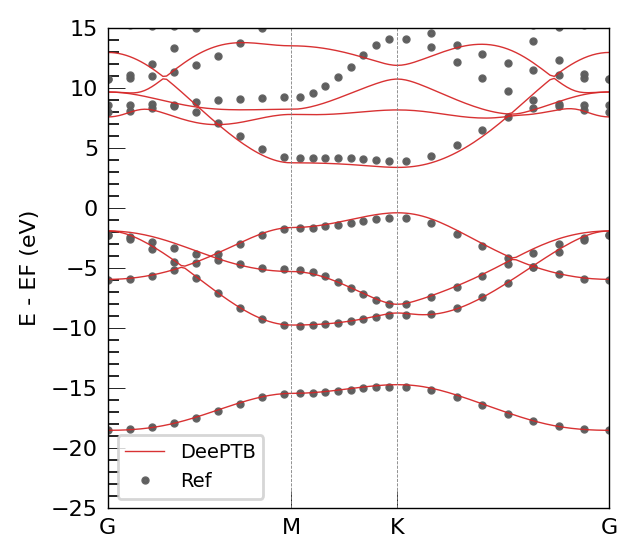

In [7]:
bcal_scc = Band(model=scc.model, results_path=None, device="cpu")
bcal_scc.eigenstatus = eigenstatus_scc
bcal_scc.band_plot(
    ref_band=str(ref_band),
    E_fermi=E_fermi,
    emin=kpath_kwargs.get("emin"),
    emax=kpath_kwargs.get("emax"),
)

For comparison, plot the same orthogonal NNSK checkpoint without SCC correction.

Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: {'B': 4.37, 'N': 4.18}
This is very dangerous, please make sure you know what you are doing.
eig_solver is not set, using default 'torch'.


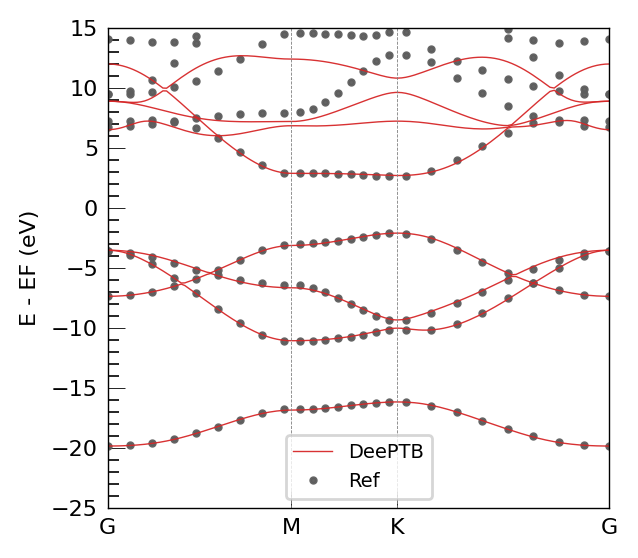

In [8]:
elec_noscc = ElecStruCal(model=model, device="cpu", eig_method="eigh")
data_noscc, eigs_noscc = elec_noscc.get_eigs(
    data=str(struct),
    klist=klist,
    AtomicData_options={"r_max": scc_params.r_max},
)

assert AtomicDataDict.OVERLAP_KEY not in data_noscc

eigenstatus_noscc = {
    "klist": klist,
    "xlist": xlist,
    "high_sym_kpoints": high_sym_kpoints,
    "labels": labels,
    "eigenvalues": data_noscc[AtomicDataDict.ENERGY_EIGENVALUE_KEY][0].detach().cpu().numpy(),
    "E_fermi": E_fermi,
}

bcal_noscc = Band(model=model, results_path=None, device="cpu")
bcal_noscc.eigenstatus = eigenstatus_noscc
bcal_noscc.band_plot(
    ref_band=str(ref_band),
    E_fermi=E_fermi,
    emin=kpath_kwargs.get("emin"),
    emax=kpath_kwargs.get("emax"),
)

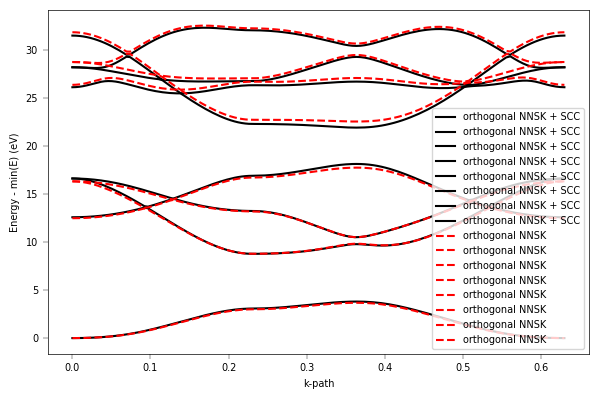

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(
    bcal_scc.eigenstatus["xlist"],
    bcal_scc.eigenstatus["eigenvalues"] - bcal_scc.eigenstatus["eigenvalues"].min(),
    "k-",
    label="orthogonal NNSK + SCC",
)
plt.plot(
    bcal_noscc.eigenstatus["xlist"],
    bcal_noscc.eigenstatus["eigenvalues"] - bcal_noscc.eigenstatus["eigenvalues"].min(),
    "r--",
    label="orthogonal NNSK",
)
plt.ylabel("Energy - min(E) (eV)")
plt.xlabel("k-path")
plt.legend()
plt.tight_layout()